# Attribution Source Analysis

Analyzing how applicants discovered the GDG program and which channels drive the most applications.

In [4]:
# Import required libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Read SQL query from attribution.sql and connect to database
db_path = '../../db/applications.db'
conn = sqlite3.connect(db_path)

# Read query from attribution.sql file
with open('attribution.sql', 'r') as f:
    query = f.read()

# Fetch attribution data
attribution_data = pd.read_sql_query(query, conn)
conn.close()

print(f"Total attribution sources: {len(attribution_data)}")
print(f"Total applicants: {attribution_data['attribution_count'].sum()}")
print("\nAttribution breakdown:")
print(attribution_data)

Total attribution sources: 7
Total applicants: 849

Attribution breakdown:
                                           source  attribution_count
0                                       Instagram                299
1                                Friend/Colleague                262
2                                     MLH Website                147
3  Another Discord Server (MLH, HackCanada, etc.)                 56
4                  GDG McMasterU's Discord Server                 41
5                                        LinkedIn                 29
6                                           Other                 15


In [6]:
# Rename attribution sources for clarity
attribution_data = attribution_data.rename(columns={
    "source": "source"  # Keep source column name
})

# Rename source values
attribution_data['source'] = attribution_data['source'].replace({
    "Instagram": "Instagram",
    "Friend/Colleague": "WOM",
    "MLH Website": "MLH Website",
    "Another Discord Server (MLH, HackCanada, etc.)": "Discord (External)",
    "GDG McMasterU's Discord Server": "Discord (GDG)",
    "Linkedin": "Linkedin",
    "Other": "Other"
})

print("Renamed attribution data:")
print(attribution_data)

Renamed attribution data:
               source  attribution_count
0           Instagram                299
1                 WOM                262
2         MLH Website                147
3  Discord (External)                 56
4       Discord (GDG)                 41
5            LinkedIn                 29
6               Other                 15


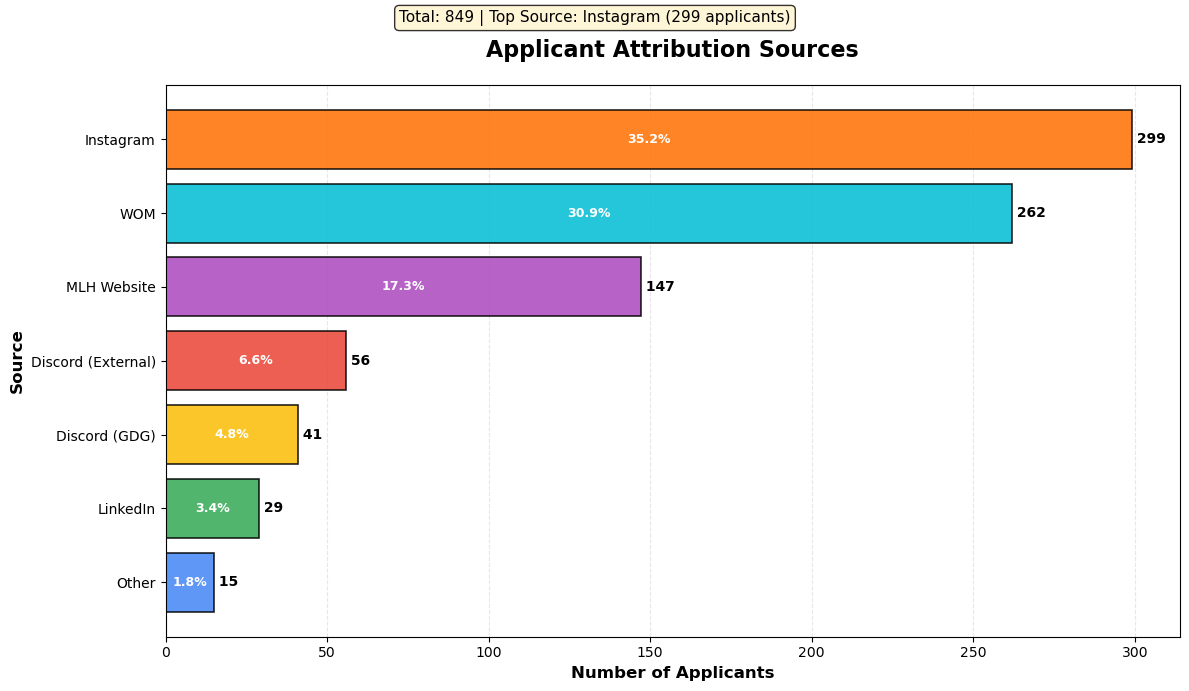

In [7]:
# Create attribution visualization
fig, ax = plt.subplots(figsize=(12, 7))

# Sort by count for clarity
attribution_data = attribution_data.sort_values('attribution_count', ascending=True)

# Create horizontal bar chart
colors = ['#4285F4', '#34A853', '#FBBC04', '#EA4335', '#AB47BC', '#00BCD4', '#FF6F00', '#9C27B0']
bars = ax.barh(attribution_data['source'], attribution_data['attribution_count'],
               color=colors[:len(attribution_data)], edgecolor='black', alpha=0.85, linewidth=1.2)

# Customize appearance
ax.set_title('Applicant Attribution Sources', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Number of Applicants', fontsize=12, fontweight='bold')
ax.set_ylabel('Source', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x', linestyle='--')
ax.set_axisbelow(True)

# Add value labels and percentages
total = attribution_data['attribution_count'].sum()
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f' {int(width)}', ha='left', va='center', fontsize=10, fontweight='bold')
    pct = (width / total) * 100
    ax.text(width/2, bar.get_y() + bar.get_height()/2.,
            f'{pct:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')

# Statistics box
top_source = attribution_data.iloc[-1]
stats_text = f'Total: {total} | Top Source: {top_source["source"]} ({top_source["attribution_count"]} applicants)'
fig.text(0.5, 0.98, stats_text, ha='center', va='top', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='#fff3cd', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()